### Gaussian Process

Firstly, we try the gaussian process removing the categorical variables to reduce the dimensionality (which would be increased by the use of Hot Ones Enconding, essential in the Gaussian Process when dealing with Categorical Variables)

Data loaded. Shape: (4864, 78)
Number of numeric columns: 74
Number of categorical columns: 2

Split logic: group_kfold_year
Development years: [np.int64(1996), np.int64(1997), np.int64(1998), np.int64(1999), np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008)]
Final test years : [np.int64(2009), np.int64(2010), np.int64(2011)]
Best params: {'gpr__alpha': 0.0001, 'gpr__kernel': 1**2 * Matern(length_scale=1, nu=1.5) + WhiteKernel(noise_level=1)}
Best inner CV MSE: 0.4817

Final test metrics
MSE: 0.6375
RMSE: 0.7984
MAE: 0.6472
R2: 0.7443

Saved predictions to: prepared\gp_results_group_kfold_year_allcrops.csv


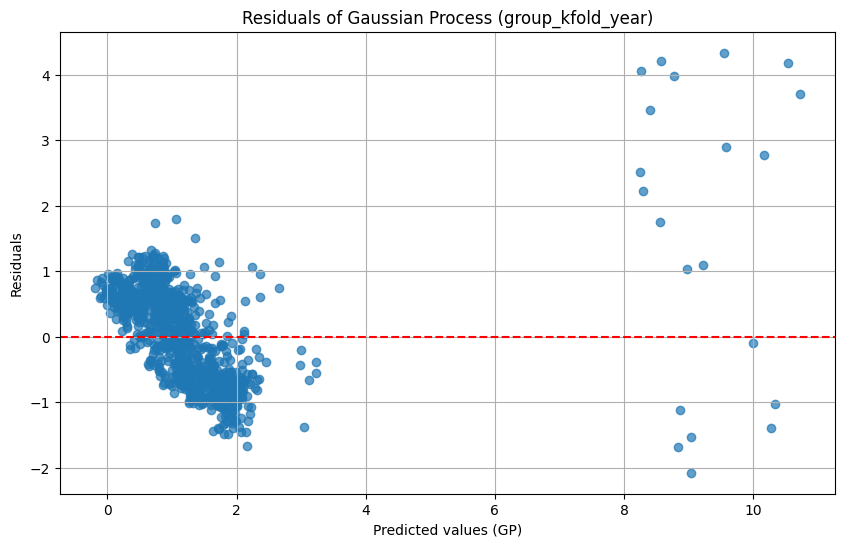

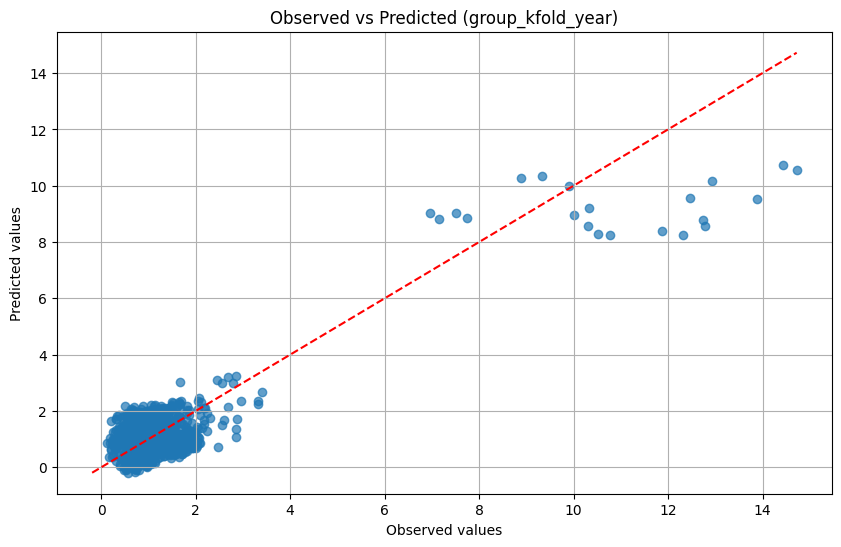

In [3]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import (
    train_test_split,
    ParameterGrid,
    GroupKFold
)
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel as C, Matern, WhiteKernel


# ============================================================
# 1. CONFIG
# ============================================================
DATA_PATH = Path("./prepared/yields_weather_by_crop.csv")
OUTDIR = Path("./prepared")
OUTDIR.mkdir(parents=True, exist_ok=True)

SPLIT_LOGIC = "group_kfold_year"   # choose from: random / last_years / random_years / group_kfold_year
CROP_SELECTED = None               # e.g. "SOYBEANS" or None
N_TEST_YEARS = 3                   # used in last_years and group_kfold_year
RANDOM_STATE = 42

# Wider ConstantKernel upper bound to address the ConvergenceWarning
GP_PARAM_GRID = {
    "gpr__alpha": [1e-6, 1e-4],
    "gpr__kernel": [
        C(1.0, (1e-3, 1e5)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e4), nu=1.5)
        + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1)),
        C(1.0, (1e-3, 1e5)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e4), nu=2.5)
        + WhiteKernel(noise_level=1.0, noise_level_bounds=(1e-5, 1e1)),
    ],
}


# ============================================================
# 2. HELPERS
# ============================================================
def evaluate_regression(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),
    }


def print_metrics(title, metrics):
    print(f"\n{title}")
    for k, v in metrics.items():
        print(f"{k}: {v:.4f}")


def build_preprocessor(num_cols, cat_cols):
    numeric_imputer = SimpleImputer(strategy="median")
    categorical_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

    preprocess_for_gp = ColumnTransformer(
        transformers=[
            ("num", Pipeline([
                ("impute", numeric_imputer),
                ("scale", StandardScaler())
            ]), num_cols),
            ("cat", Pipeline([
                ("onehot", categorical_encoder)
            ]), cat_cols),
        ],
        remainder="drop",
    )
    return preprocess_for_gp


def build_gp_pipeline(num_cols, cat_cols, kernel, alpha):
    preprocess = build_preprocessor(num_cols, cat_cols)

    model = Pipeline([
        ("preprocess", preprocess),
        ("gpr", GaussianProcessRegressor(
            kernel=kernel,
            alpha=alpha,
            normalize_y=True,
            n_restarts_optimizer=0,
            random_state=RANDOM_STATE
        ))
    ])
    return model


def tune_on_validation_split(
    X_train, y_train, X_val, y_val, num_cols, cat_cols, param_grid
):
    best_score = np.inf
    best_params = None
    best_model = None

    for params in ParameterGrid(param_grid):
        model = build_gp_pipeline(
            num_cols=num_cols,
            cat_cols=cat_cols,
            kernel=params["gpr__kernel"],
            alpha=params["gpr__alpha"],
        )
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        val_mse = mean_squared_error(y_val, val_pred)

        if val_mse < best_score:
            best_score = val_mse
            best_params = params
            best_model = model

    return best_params, best_score, best_model


def tune_with_inner_groupkfold(
    X_dev, y_dev, groups_dev, num_cols, cat_cols, param_grid, n_splits=5
):
    gkf = GroupKFold(n_splits=n_splits)

    best_score = np.inf
    best_params = None

    for params in ParameterGrid(param_grid):
        fold_mses = []

        for tr_idx, val_idx in gkf.split(X_dev, y_dev, groups=groups_dev):
            X_tr = X_dev.iloc[tr_idx]
            X_val = X_dev.iloc[val_idx]
            y_tr = y_dev.iloc[tr_idx]
            y_val = y_dev.iloc[val_idx]

            model = build_gp_pipeline(
                num_cols=num_cols,
                cat_cols=cat_cols,
                kernel=params["gpr__kernel"],
                alpha=params["gpr__alpha"],
            )
            model.fit(X_tr, y_tr)
            val_pred = model.predict(X_val)
            fold_mses.append(mean_squared_error(y_val, val_pred))

        avg_mse = np.mean(fold_mses)

        if avg_mse < best_score:
            best_score = avg_mse
            best_params = params

    return best_params, best_score


# ============================================================
# 3. LOAD DATA
# ============================================================
df = pd.read_csv(DATA_PATH)
df.columns = df.columns.str.strip()
df["Municipality"] = df["Municipality"].astype(str).str.strip().str.upper()
df["Crop"] = df["Crop"].astype(str).str.strip().str.upper()
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype(int)

if CROP_SELECTED is not None:
    df = df[df["Crop"] == CROP_SELECTED].copy()

if df.empty:
    raise ValueError("The dataframe is empty after filtering.")

print("Data loaded. Shape:", df.shape)

# ============================================================
# 4. FEATURES / TARGET
# ============================================================
target_col = "Mean_Yield"
cat_cols = ["Crop", "Municipality"]

num_cols = [
    c for c in df.columns
    if pd.api.types.is_numeric_dtype(df[c]) and c != target_col
]

# Exclude Year as predictor if the goal is climate/location -> yield
if "Year" in num_cols:
    num_cols.remove("Year")

X = df[num_cols + cat_cols].copy()
y = df[target_col].copy()
years = df["Year"].copy()

print("Number of numeric columns:", len(num_cols))
print("Number of categorical columns:", len(cat_cols))


# ============================================================
# 5. SPLIT LOGIC
# ============================================================
if SPLIT_LOGIC == "random":
    X_train, X_tmp, y_train, y_tmp = train_test_split(
        X, y, test_size=0.4, random_state=RANDOM_STATE, shuffle=True
    )
    X_val, X_test, y_val, y_test = train_test_split(
        X_tmp, y_tmp, test_size=0.5, random_state=RANDOM_STATE, shuffle=True
    )

    best_params, best_val_mse, _ = tune_on_validation_split(
        X_train, y_train, X_val, y_val, num_cols, cat_cols, GP_PARAM_GRID
    )

    X_refit = pd.concat([X_train, X_val], axis=0)
    y_refit = pd.concat([y_train, y_val], axis=0)

    final_model = build_gp_pipeline(
        num_cols, cat_cols,
        kernel=best_params["gpr__kernel"],
        alpha=best_params["gpr__alpha"]
    )
    final_model.fit(X_refit, y_refit)
    y_test_pred = final_model.predict(X_test)

    metrics = evaluate_regression(y_test, y_test_pred)

    print("\nSplit logic: random")
    print("Best params:", best_params)
    print(f"Best validation MSE: {best_val_mse:.4f}")
    print_metrics("Final test metrics", metrics)

    results = X_test.copy()
    results["Year"] = df.loc[X_test.index, "Year"]
    results["Municipality"] = df.loc[X_test.index, "Municipality"]
    results["Crop"] = df.loc[X_test.index, "Crop"]
    results["Mean_Yield"] = y_test
    results["GP_Pred"] = y_test_pred

elif SPLIT_LOGIC == "last_years":
    all_years = sorted(years.unique())
    test_years = all_years[-N_TEST_YEARS:]
    remaining_years = all_years[:-N_TEST_YEARS]

    df_dev = df[df["Year"].isin(remaining_years)].copy()
    df_test = df[df["Year"].isin(test_years)].copy()

    X_dev = df_dev[num_cols + cat_cols].copy()
    y_dev = df_dev[target_col].copy()
    X_test = df_test[num_cols + cat_cols].copy()
    y_test = df_test[target_col].copy()

    X_train, X_val, y_train, y_val = train_test_split(
        X_dev, y_dev, test_size=0.25, random_state=RANDOM_STATE, shuffle=True
    )

    best_params, best_val_mse, _ = tune_on_validation_split(
        X_train, y_train, X_val, y_val, num_cols, cat_cols, GP_PARAM_GRID
    )

    final_model = build_gp_pipeline(
        num_cols, cat_cols,
        kernel=best_params["gpr__kernel"],
        alpha=best_params["gpr__alpha"]
    )
    final_model.fit(X_dev, y_dev)
    y_test_pred = final_model.predict(X_test)

    metrics = evaluate_regression(y_test, y_test_pred)

    print("\nSplit logic: last_years")
    print("Test years:", test_years)
    print("Best params:", best_params)
    print(f"Best validation MSE: {best_val_mse:.4f}")
    print_metrics("Final test metrics", metrics)

    results = df_test[["Year", "Municipality", "Crop", "Mean_Yield"]].copy()
    results["GP_Pred"] = y_test_pred

elif SPLIT_LOGIC == "random_years":
    all_years = np.array(sorted(years.unique()))
    rng = np.random.default_rng(RANDOM_STATE)
    shuffled_years = rng.permutation(all_years)

    n_test = N_TEST_YEARS
    n_val = N_TEST_YEARS

    test_years = shuffled_years[:n_test]
    val_years = shuffled_years[n_test:n_test + n_val]
    train_years = shuffled_years[n_test + n_val:]

    df_train = df[df["Year"].isin(train_years)].copy()
    df_val = df[df["Year"].isin(val_years)].copy()
    df_test = df[df["Year"].isin(test_years)].copy()

    X_train = df_train[num_cols + cat_cols].copy()
    y_train = df_train[target_col].copy()
    X_val = df_val[num_cols + cat_cols].copy()
    y_val = df_val[target_col].copy()
    X_test = df_test[num_cols + cat_cols].copy()
    y_test = df_test[target_col].copy()

    best_params, best_val_mse, _ = tune_on_validation_split(
        X_train, y_train, X_val, y_val, num_cols, cat_cols, GP_PARAM_GRID
    )

    X_refit = pd.concat([X_train, X_val], axis=0)
    y_refit = pd.concat([y_train, y_val], axis=0)

    final_model = build_gp_pipeline(
        num_cols, cat_cols,
        kernel=best_params["gpr__kernel"],
        alpha=best_params["gpr__alpha"]
    )
    final_model.fit(X_refit, y_refit)
    y_test_pred = final_model.predict(X_test)

    metrics = evaluate_regression(y_test, y_test_pred)

    print("\nSplit logic: random_years")
    print("Train years:", sorted(train_years))
    print("Val years  :", sorted(val_years))
    print("Test years :", sorted(test_years))
    print("Best params:", best_params)
    print(f"Best validation MSE: {best_val_mse:.4f}")
    print_metrics("Final test metrics", metrics)

    results = df_test[["Year", "Municipality", "Crop", "Mean_Yield"]].copy()
    results["GP_Pred"] = y_test_pred

elif SPLIT_LOGIC == "group_kfold_year":
    all_years = sorted(years.unique())
    test_years = all_years[-N_TEST_YEARS:]
    dev_years = all_years[:-N_TEST_YEARS]

    df_dev = df[df["Year"].isin(dev_years)].copy()
    df_test = df[df["Year"].isin(test_years)].copy()

    X_dev = df_dev[num_cols + cat_cols].copy()
    y_dev = df_dev[target_col].copy()
    groups_dev = df_dev["Year"].copy()

    X_test = df_test[num_cols + cat_cols].copy()
    y_test = df_test[target_col].copy()

    n_inner_splits = min(5, len(np.unique(groups_dev)))
    if n_inner_splits < 2:
        raise ValueError("Not enough distinct training years for inner GroupKFold.")

    best_params, best_cv_mse = tune_with_inner_groupkfold(
        X_dev, y_dev, groups_dev,
        num_cols, cat_cols, GP_PARAM_GRID,
        n_splits=n_inner_splits
    )

    final_model = build_gp_pipeline(
        num_cols, cat_cols,
        kernel=best_params["gpr__kernel"],
        alpha=best_params["gpr__alpha"]
    )
    final_model.fit(X_dev, y_dev)
    y_test_pred = final_model.predict(X_test)

    metrics = evaluate_regression(y_test, y_test_pred)

    print("\nSplit logic: group_kfold_year")
    print("Development years:", dev_years)
    print("Final test years :", test_years)
    print("Best params:", best_params)
    print(f"Best inner CV MSE: {best_cv_mse:.4f}")
    print_metrics("Final test metrics", metrics)

    results = df_test[["Year", "Municipality", "Crop", "Mean_Yield"]].copy()
    results["GP_Pred"] = y_test_pred

else:
    raise ValueError(f"Unknown SPLIT_LOGIC: {SPLIT_LOGIC}")


# ============================================================
# 6. SAVE RESULTS
# ============================================================
results["Residual"] = results["Mean_Yield"] - results["GP_Pred"]
results["Abs_Error"] = np.abs(results["Residual"])

suffix = "allcrops" if CROP_SELECTED is None else CROP_SELECTED.lower().replace(" ", "_")
outpath = OUTDIR / f"gp_results_{SPLIT_LOGIC}_{suffix}.csv"
results.to_csv(outpath, index=False)

print("\nSaved predictions to:", outpath)


# ============================================================
# 7. PLOTS
# ============================================================
plt.figure(figsize=(10, 6))
plt.scatter(results["GP_Pred"], results["Residual"], alpha=0.7)
plt.axhline(0, color="r", linestyle="--")
plt.xlabel("Predicted values (GP)")
plt.ylabel("Residuals")
plt.title(f"Residuals of Gaussian Process ({SPLIT_LOGIC})")
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(results["Mean_Yield"], results["GP_Pred"], alpha=0.7)
mn = min(results["Mean_Yield"].min(), results["GP_Pred"].min())
mx = max(results["Mean_Yield"].max(), results["GP_Pred"].max())
plt.plot([mn, mx], [mn, mx], "r--")
plt.xlabel("Observed values")
plt.ylabel("Predicted values")
plt.title(f"Observed vs Predicted ({SPLIT_LOGIC})")
plt.grid(True)
plt.show()